In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 │ ⚙️ CONFIG + LOAD DATASET
# ─────────────────────────────────────────────────────────────────────────────
import os
import re
import json
import random
from pathlib import Path
from datetime import datetime

MODEL_NAME = "/home/drnguyenvinh/Exam-Assistant/Bench_mark/models/qwen3_examassist_merged_4b_qlora_domain"
DATASET_PATH = "test-final_v3.jsonl"

RANDOM_SEED = 42
MAX_NEW_TOKENS = 128
TEMPERATURE = 0.0
BATCH_SIZE = 8
MAX_MODEL_LEN = 2048
GPU_MEM_UTIL = 0.80

RUN_NAME = "qwen3_vl_4b_finetuned(qlora)_domain_test"
OUTPUT_DIR = Path(f"./benchmark_outputs/{RUN_NAME}_{datetime.now().strftime('%Y%m%d_%H%M%S')}")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("OUTPUT_DIR:", OUTPUT_DIR.resolve())

def extract_context_question(user_content):
    user_content = str(user_content).strip()

    context_match = re.search(
        r"(?:Context|Ngữ cảnh)\s*:\s*(.*?)\s*(?:Question|Câu hỏi)\s*:",
        user_content,
        flags=re.DOTALL | re.IGNORECASE
    )

    question_match = re.search(
        r"(?:Question|Câu hỏi)\s*:\s*(.*)",
        user_content,
        flags=re.DOTALL | re.IGNORECASE
    )

    context = context_match.group(1).strip() if context_match else ""
    question = question_match.group(1).strip() if question_match else ""

    return context, question

REFUSAL_GOLD = "Không có thông tin trong ngữ cảnh được cung cấp."

def normalize_text(text):
    text = str(text).lower().strip()
    text = re.sub(r"\s+", " ", text)
    return text

REFUSAL_GOLD_NORM = normalize_text(REFUSAL_GOLD)

def is_gold_unanswerable(ans):
    return normalize_text(ans) == REFUSAL_GOLD_NORM

samples = []

with open(DATASET_PATH, "r", encoding="utf-8") as f:
    for idx, line in enumerate(f):
        item = json.loads(line)
        messages = item["messages"]

        system_msg = messages[0]["content"].strip()
        user_msg = messages[1]["content"].strip()
        gold_answer = messages[2]["content"].strip()

        context, question = extract_context_question(user_msg)

        samples.append({
            "id": f"sample_{idx}",
            "context": context,
            "question": question,
            "gold_answers": [gold_answer],
            "gold_answer": gold_answer,

            "is_unanswerable":
                is_gold_unanswerable(gold_answer),

            "messages": [
                {"role":"system","content":system_msg},
                {"role":"user","content":user_msg}
            ]
        })

print("Loaded samples:", len(samples))
print("Example question:", samples[0]["question"])
print("Example gold:", samples[0]["gold_answer"])

OUTPUT_DIR: /home/drnguyenvinh/Exam-Assistant/Bench_mark/benchmark_outputs/qwen3_vl_4b_finetuned(qlora)_domain_test_20260710_152729
Loaded samples: 430
Example question: Tài khoản đăng nhập EOS là tài khoản nào?
Example gold: Tài khoản đăng nhập EOS/PEA chính là tài khoản Wi-Fi FU-Student của sinh viên.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 │ 🚀 LOAD QWEN3-VL-4B-INSTRUCT WITH vLLM
# ─────────────────────────────────────────────────────────────────────────────
import io
import sys
import os
import subprocess
from transformers import AutoTokenizer
from vllm import LLM, SamplingParams

def _patch_jupyter_streams():
    _null_fd = os.open(os.devnull, os.O_WRONLY)

    class _FilenoPatchedStream:
        def __init__(self, original, null_fd):
            object.__setattr__(self, "_orig", original)
            object.__setattr__(self, "_null_fd", null_fd)

        def fileno(self):
            return object.__getattribute__(self, "_null_fd")

        def write(self, s):
            return object.__getattribute__(self, "_orig").write(s)

        def flush(self):
            return object.__getattribute__(self, "_orig").flush()

        def isatty(self):
            return False

        def readable(self):
            return False

        def writable(self):
            return True

        def __getattr__(self, name):
            return getattr(object.__getattribute__(self, "_orig"), name)

    for stream_name in ("stdout", "stderr"):
        stream = getattr(sys, stream_name)
        try:
            stream.fileno()
        except io.UnsupportedOperation:
            setattr(sys, stream_name, _FilenoPatchedStream(stream, _null_fd))

_patch_jupyter_streams()

print(subprocess.getoutput("nvidia-smi"))

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True
)

llm = LLM(
    model=MODEL_NAME,
    trust_remote_code=True,
    dtype="half",
    quantization=None,
    max_model_len=MAX_MODEL_LEN,
    gpu_memory_utilization=GPU_MEM_UTIL,
    enforce_eager=True,
    max_num_seqs=BATCH_SIZE,
    limit_mm_per_prompt={"image": 0}
)

sampling_params = SamplingParams(
    temperature=TEMPERATURE,
    max_tokens=MAX_NEW_TOKENS
)

print("✅ Model loaded successfully.")

/opt/miniconda3/envs/qwen3_bm/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/miniconda3/envs/qwen3_bm/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Fri Jul 10 15:27:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.95.05              Driver Version: 580.95.05      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4090        Off |   00000000:01:00.0  On |                  Off |
|  0%   54C    P5             29W /  450W |     576MiB /  24564MiB |     20%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

2026-07-10 15:27:33,959	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


INFO 07-10 15:27:33 [scheduler.py:239] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 07-10 15:27:33 [vllm.py:886] Asynchronous scheduling is enabled.
WARNING 07-10 15:27:33 [vllm.py:942] Enforce eager set, disabling torch.compile and CUDAGraphs. This is equivalent to setting -cc.mode=none -cc.cudagraph_mode=none
WARNING 07-10 15:27:33 [vllm.py:960] Inductor compilation was disabled by user settings, optimizations settings that are only active during inductor compilation will be ignored.
INFO 07-10 15:27:33 [kernel.py:212] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['vllm_c', 'native'], fused_add_rms_norm=['vllm_c', 'native'])
INFO 07-10 15:27:33 [vllm.py:1135] Cudagraph is disabled under eager mode
INFO 07-10 15:27:33 [compilation.py:303] Enabled custom fusions: norm_quant, act_quant


[transformers] `Qwen2VLImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Qwen2VLImageProcessor` instead.
[transformers] The `use_fast` parameter is deprecated and will be removed in a future version. Use `backend="torchvision"` instead of `use_fast=True`, or `backend="pil"` instead of `use_fast=False`.


(EngineCore pid=2094472) INFO 07-10 15:27:37 [core.py:109] Initializing a V1 LLM engine (v0.21.0) with config: model='/home/drnguyenvinh/Exam-Assistant/Bench_mark/models/qwen3_examassist_merged_4b_qlora_domain', speculative_config=None, tokenizer='/home/drnguyenvinh/Exam-Assistant/Bench_mark/models/qwen3_examassist_merged_4b_qlora_domain', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=True, dtype=torch.float16, max_seq_len=2048, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, data_parallel_size=1, decode_context_parallel_size=1, dcp_comm_backend=ag_rs, disable_custom_all_reduce=False, quantization=None, quantization_config=None, enforce_eager=True, enable_return_routed_experts=False, kv_cache_dtype=auto, device_config=cuda, structured_outputs_config=StructuredOutputsConfig(backend='auto', disable_any_whitespace=False, disable_additional_properties=False, reasoning_parser='', reasoning_par

Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:01<00:00,  1.32s/it]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:01<00:00,  1.32s/it]
(EngineCore pid=2094472) 


(EngineCore pid=2094472) INFO 07-10 15:27:40 [default_loader.py:397] Loading weights took 1.47 seconds
(EngineCore pid=2094472) INFO 07-10 15:27:40 [gpu_model_runner.py:4959] Model loading took 8.69 GiB memory and 1.614202 seconds
(EngineCore pid=2094472) INFO 07-10 15:27:40 [gpu_model_runner.py:5920] Encoder cache will be initialized with a budget of 12288 tokens, and profiled with 1 video items of the maximum feature size.
(EngineCore pid=2094472) INFO 07-10 15:27:44 [gpu_worker.py:462] Available KV cache memory: 8.61 GiB
(EngineCore pid=2094472) INFO 07-10 15:27:44 [kv_cache_utils.py:1710] GPU KV cache size: 62,656 tokens
(EngineCore pid=2094472) INFO 07-10 15:27:44 [kv_cache_utils.py:1711] Maximum concurrency for 2,048 tokens per request: 30.59x
(EngineCore pid=2094472) INFO 07-10 15:27:44 [kernel_warmup.py:44] Skipping FlashInfer autotune because it is disabled.
(EngineCore pid=2094472) INFO 07-10 15:27:44 [jit_monitor.py:54] Kernel JIT monitor activated — Triton JIT compilations 

(EngineCore pid=2094472) WARNING 07-10 15:27:44 [jit_monitor.py:103] Triton kernel JIT compilation during inference: _compute_slot_mapping_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.
(EngineCore pid=2094472) WARNING 07-10 15:27:53 [jit_monitor.py:103] Triton kernel JIT compilation during inference: _triton_mrope_forward. This causes a latency spike; consider extending warmup to cover this shape/config.


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 │ 🔮 INFERENCE
# ─────────────────────────────────────────────────────────────────────────────
import time
from tqdm import tqdm

prompts = []

for s in samples:
    prompt = tokenizer.apply_chat_template(
        s["messages"],
        tokenize=False,
        add_generation_prompt=True
    )
    prompts.append(prompt)

print("Total prompts:", len(prompts))
print("Prompt preview:")
print(prompts[0][:1000])

start_time = time.time()

outputs = llm.generate(
    prompts,
    sampling_params,
    use_tqdm=True
)

total_time = time.time() - start_time

predictions = [
    output.outputs[0].text.strip()
    for output in outputs
]

for s, pred in zip(samples, predictions):
    s["prediction"] = pred

print("✅ Inference completed")
print("Total time:", round(total_time, 2), "seconds")
print("Avg latency:", round(total_time / len(samples), 4), "sec/sample")
print("Throughput:", round(len(samples) / total_time, 2), "samples/sec")

print("\nPrediction example:")
print(predictions[0])

Total prompts: 430
Prompt preview:
<|im_start|>system
Bạn là trợ lý AI hỗ trợ giám thị coi thi. Chỉ trả lời dựa trên ngữ cảnh được cung cấp. Trả lời ngắn gọn, chính xác và không suy diễn ngoài dữ liệu.<|im_end|>
<|im_start|>user
Context:
Sự cố 01. Tài khoản đăng nhập EOS và quản lý mật khẩu. Trong kỳ thi EOS, mạng Wi-Fi sử dụng để làm bài là FU-Exam với mật khẩu FU-Exam@. Tài khoản đăng nhập hệ thống thi EOS/PEA chính là tài khoản Wi-Fi FU-Student của sinh viên. Do đó, nếu sinh viên quên mật khẩu đăng nhập EOS thì cần kiểm tra hoặc đặt lại mật khẩu tài khoản Wi-Fi FU-Student. Nếu sinh viên không nhớ mật khẩu Wi-Fi FU-Student, trước tiên cần kiểm tra hộp thư email bằng cách tìm kiếm các từ khóa như Wifi, EOS, IT, Account hoặc Pass để tìm email chứa thông tin tài khoản do nhà trường gửi. Nếu cần đổi mật khẩu, sinh viên truy cập http://reset.fun.cantho/, nhập tài khoản đăng nhập và địa chỉ email để nhận mật khẩu tạm thời. Sau khi nhận email, sinh viên quay lại trang reset, nhập Username, 

Processed prompts: 100%|██████████| 430/430 [00:08<00:00, 48.47it/s, est. speed input: 15621.29 toks/s, output: 604.62 toks/s]

✅ Inference completed
Total time: 9.08 seconds
Avg latency: 0.0211 sec/sample
Throughput: 47.36 samples/sec

Prediction example:
Tài khoản Wi-Fi FU-Student.


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 | EVALUATION METRICS — LLM-AS-A-JUDGE (refusal / hallucination / correctness / faithfulness)
#            + RULE-BASED METRICS (EM / F1 / ROUGE-L / Containment / Context Recall / Token-Faithfulness)
# ─────────────────────────────────────────────────────────────────────────────

import os
import re
import json
import unicodedata
import numpy as np
import pandas as pd
from collections import Counter
from tqdm import tqdm
import concurrent.futures
from openai import OpenAI
from pydantic import BaseModel, Field
from dotenv import load_dotenv

# ── LLM Judge setup ───────────────────────────────────────────────────────────
load_dotenv()
api_key = os.getenv("OPENAI_API_KEY")
if not api_key:
    raise ValueError("Không tìm thấy OPENAI_API_KEY trong file .env!")
client = OpenAI(api_key=api_key)
JUDGE_MODEL = "gpt-4o-mini"

REFUSAL_GOLD = "Không có thông tin trong ngữ cảnh được cung cấp."

from pydantic import BaseModel, Field

class JudgeResult(BaseModel):
    # ĐƯA REASONING LÊN ĐẦU ĐỂ ÉP MÔ HÌNH SUY LUẬN TRƯỚC KHI CHẤM ĐIỂM (Chain-of-Thought)
    reasoning: str = Field(description="Phân tích và giải thích ngắn gọn (dưới 30 từ) lý do chấm điểm trước khi đưa ra kết quả.")
    
    is_refusal: bool = Field(description="True nếu mô hình từ chối trả lời vì thiếu thông tin trong ngữ cảnh.")
    is_hallucination: bool = Field(description="True nếu mô hình tự bịa ra thông tin không hề có trong ngữ cảnh (chỉ tính thông tin sai lệch, không tính diễn đạt khác).")
    
    # CHUẨN HÓA THANG ĐIỂM
    faithfulness: float = Field(description="Độ trung thành với ngữ cảnh. Chỉ dùng các mức: 0.0 (bịa đặt hoàn toàn), 0.5 (có dựa vào ngữ cảnh nhưng suy diễn thêm), 1.0 (hoàn toàn dựa vào ngữ cảnh hoặc từ chối đúng vì ngữ cảnh không có).")
    correctness: float = Field(description="Độ chính xác so với đáp án chuẩn. Chỉ dùng các mức: 0.0 (sai hoàn toàn), 0.5 (đúng một phần hoặc thiếu ý chính), 1.0 (đúng toàn bộ ý nghĩa cốt lõi của đáp án chuẩn).")


def evaluate_with_llm(context: str, question: str, gold: str, pred: str) -> dict:
    prompt = f"""Bạn là một giám khảo AI chuyên nghiệp, khách quan.
Nhiệm vụ: Đánh giá câu trả lời của [Mô hình] dựa trên [Ngữ cảnh] do hệ thống RAG cung cấp và [Đáp án chuẩn] của con người.

[Dữ liệu]
- Ngữ cảnh: {context}
- Câu hỏi: {question}
- Đáp án chuẩn: {gold}
- Mô hình trả lời: {pred}

[Tiêu chí chấm điểm khắt khe]
1. Về Từ chối (Refusal): Nếu mô hình nói rằng không có đủ thông tin để trả lời, set is_refusal = True.
2. Từ chối đúng (Expected Refusal): Nếu [Đáp án chuẩn] thể hiện việc không thể trả lời, và [Mô hình] cũng từ chối -> Đánh giá faithfulness = 1.0 và correctness = 1.0.
3. Ảo tưởng (Hallucination): Nếu [Mô hình] đưa ra chi tiết cụ thể (tên, số, quy định) KHÔNG xuất hiện trong [Ngữ cảnh], set is_hallucination = True và faithfulness = 0.0.
4. Correctness: Chỉ đánh giá sự tương đồng về NỘI DUNG Ý NGHĨA với [Đáp án chuẩn], bỏ qua sự khác biệt về văn phong hay cách dùng từ.

Hãy suy luận kỹ (reasoning) trước khi chốt điểm số.
"""
    try:
        response = client.beta.chat.completions.parse(
            model=JUDGE_MODEL, # GPT-4o-mini hoặc Claude 3.5 Sonnet
            messages=[
                {"role": "system", "content": "Bạn là giám khảo AI tiếng Việt chuyên nghiệp, nghiêm ngặt và công tâm."},
                {"role": "user", "content": prompt}
            ],
            response_format=JudgeResult,
            temperature=0.0,
            seed=42
        )
        return response.choices[0].message.parsed.model_dump()
    except Exception as e:
        return {
            "reasoning": f"Lỗi API: {str(e)}",
            "is_refusal": False, 
            "is_hallucination": False,
            "faithfulness": 0.0, 
            "correctness": 0.0
        }
    
# ── Text utilities ────────────────────────────────────────────────────────────
def normalize_text(text):
    text = str(text).lower().strip()
    text = unicodedata.normalize("NFC", text)
    text = re.sub(
        r"[^\w\sàáạảãâầấậẩẫăằắặẳẵèéẹẻẽêềếệểễìíịỉĩòóọỏõôồốộổỗơờớợởỡùúụủũưừứựửữỳýỵỷỹđ]",
        " ", text
    )
    text = re.sub(r"\s+", " ", text).strip()
    return text

def is_gold_unanswerable(gold):
    return normalize_text(REFUSAL_GOLD) in normalize_text(gold)

# ── Standard QA metrics (rule-based, giữ nguyên từ cell gốc "Answerable/Unanswerable") ──
def compute_em(pred, gold):
    return int(normalize_text(pred) == normalize_text(gold))

def compute_f1(pred, gold):
    pred_tokens = normalize_text(pred).split()
    gold_tokens = normalize_text(gold).split()
    if not pred_tokens and not gold_tokens:
        return 1.0
    if not pred_tokens or not gold_tokens:
        return 0.0
    common = Counter(pred_tokens) & Counter(gold_tokens)
    num_same = sum(common.values())
    if num_same == 0:
        return 0.0
    precision = num_same / len(pred_tokens)
    recall    = num_same / len(gold_tokens)
    return 2 * precision * recall / (precision + recall)

def lcs_length(x, y):
    dp = [[0] * (len(y) + 1) for _ in range(len(x) + 1)]
    for i in range(1, len(x) + 1):
        for j in range(1, len(y) + 1):
            if x[i - 1] == y[j - 1]:
                dp[i][j] = dp[i - 1][j - 1] + 1
            else:
                dp[i][j] = max(dp[i - 1][j], dp[i][j - 1])
    return dp[-1][-1]

def compute_rouge_l(pred, gold):
    pred_tokens = normalize_text(pred).split()
    gold_tokens = normalize_text(gold).split()
    if not pred_tokens or not gold_tokens:
        return 0.0
    lcs = lcs_length(pred_tokens, gold_tokens)
    precision = lcs / len(pred_tokens)
    recall    = lcs / len(gold_tokens)
    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)

def compute_containment(pred, gold, f1_threshold=0.8):
    pred_norm = normalize_text(pred)
    gold_norm = normalize_text(gold)
    if not gold_norm:
        return 0
    # Pass nếu chứa nguyên văn
    if gold_norm in pred_norm:
        return 1
    # Pass nếu gần tương đương về mặt token
    if compute_f1(pred, gold) >= f1_threshold:
        return 1
    return 0

# ── Rule-based Faithfulness (token-level precision so với context) ───────────
def compute_faithfulness(pred: str, context: str) -> float:
    """
    Token-level precision: tỷ lệ token trong prediction xuất hiện trong context.
    Cao → prediction bám sát context (faithful).
    Thấp → prediction chứa nhiều nội dung không có trong context (hallucination).
    """
    pred_tokens    = normalize_text(pred).split()
    context_tokens = set(normalize_text(context).split())
    if not pred_tokens:
        return 1.0
    matched = sum(1 for t in pred_tokens if t in context_tokens)
    return matched / len(pred_tokens)

# ── Context Recall (token-level recall của gold so với context) ──────────────
def compute_context_recall(gold: str, context: str, gold_unanswerable: bool) -> float:
    """
    Đo mức độ context hỗ trợ gold answer.
    Với unanswerable: luôn = 1.0 vì context đúng là thiếu thông tin.
    """
    if gold_unanswerable:
        return 1.0
    gold_tokens    = normalize_text(gold).split()
    context_tokens = set(normalize_text(context).split())
    if not gold_tokens:
        return 1.0
    matched = sum(1 for t in gold_tokens if t in context_tokens)
    return matched / len(gold_tokens)

# ── Gọi LLM Judge song song (Parallel Execution) ─────────────────────────────
print("Đang gọi LLM Judge để chấm điểm (có thể mất 10-30 giây)...")
judged_results = [None] * len(samples)
with concurrent.futures.ThreadPoolExecutor(max_workers=10) as executor:
    future_to_idx = {
        executor.submit(
            evaluate_with_llm,
            s.get("context", ""), s["question"], s["gold_answer"], s["prediction"]
        ): idx
        for idx, s in enumerate(samples)
    }
    for future in tqdm(concurrent.futures.as_completed(future_to_idx), total=len(samples), desc="Judging"):
        idx = future_to_idx[future]
        judged_results[idx] = future.result()

# ── Main evaluation loop (rule-based metrics + LLM-judge metrics) ────────────
rows = []

for idx, s in enumerate(samples):
    pred             = s["prediction"]
    gold             = s["gold_answer"]
    gold_answers_all = s.get("gold_answers", [gold])
    context          = s.get("context", "")

    # Ưu tiên field is_unanswerable có sẵn trong dataset, fallback sang so khớp text với REFUSAL_GOLD
    gold_unanswerable = s.get("is_unanswerable", is_gold_unanswerable(gold))
    answerable        = not gold_unanswerable

    # ── LLM-as-judge quyết định refusal / hallucination / faithfulness / correctness ──
    judge             = judged_results[idx]
    pred_refusal      = bool(judge["is_refusal"])
    is_hallucination  = int(judge["is_hallucination"])
    llm_faithfulness  = judge["faithfulness"]
    llm_correctness   = judge["correctness"]
    judge_reasoning   = judge["reasoning"]

    # ── Rule-based (giữ nguyên logic cell "Answerable/Unanswerable + Faithfulness + Context Recall") ──
    rule_faithfulness = compute_faithfulness(pred, context)
    context_recall    = compute_context_recall(gold, context, gold_unanswerable)
    pred_tokens_count = len(tokenizer.encode(pred, add_special_tokens=False))

    if answerable:
        em          = max(compute_em(pred, g)          for g in gold_answers_all)
        f1          = max(compute_f1(pred, g)          for g in gold_answers_all)
        rouge_l     = max(compute_rouge_l(pred, g)     for g in gold_answers_all)
        containment = max(compute_containment(pred, g) for g in gold_answers_all)

        false_refusal   = int(pred_refusal)
        correct_refusal = 0
    else:
        em          = int(pred_refusal)
        f1          = 1.0 if pred_refusal else 0.0
        rouge_l     = 1.0 if pred_refusal else 0.0
        containment = 0

        false_refusal   = 0
        correct_refusal = int(pred_refusal)

    rows.append({
        "id":               s["id"],
        "question":         s["question"],
        "context":          context,
        "gold_answer":      gold,
        "gold_answers_all": json.dumps(gold_answers_all, ensure_ascii=False),
        "prediction":       pred,
        "pred_len_tokens":  pred_tokens_count,

        "is_answerable":    int(answerable),
        "is_unanswerable":  int(not answerable),
        "pred_refusal":     int(pred_refusal),

        # Rule-based standard metrics
        "em":               em,
        "f1":               f1,
        "rouge_l":          rouge_l,
        "containment":      containment,

        # Rule-based faithfulness / context recall
        "faithfulness":     rule_faithfulness,
        "context_recall":   context_recall,

        # LLM-as-judge metrics
        "llm_correctness":  llm_correctness,
        "llm_faithfulness": llm_faithfulness,
        "judge_reasoning":  judge_reasoning,

        "false_refusal":    false_refusal,
        "correct_refusal":  correct_refusal,
        "hallucination":    is_hallucination,

        "gold_len_words":   len(gold.split()),
        "pred_len_words":   len(pred.split())
    })

df = pd.DataFrame(rows)

answerable_df   = df[df["is_answerable"]   == 1]
unanswerable_df = df[df["is_unanswerable"] == 1]

summary = {
    "model":   MODEL_NAME,
    "dataset": DATASET_PATH,
    "num_samples": len(df),
    "avg_pred_len_tokens": df["pred_len_tokens"].mean(),

    "answerable_samples":   len(answerable_df),
    "unanswerable_samples": len(unanswerable_df),

    # ── Rule-based standard metrics ──
    "overall_em":      df["em"].mean()      * 100,
    "overall_f1":      df["f1"].mean()      * 100,
    "overall_rouge_l": df["rouge_l"].mean() * 100,

    "answerable_em":          answerable_df["em"].mean()          * 100 if len(answerable_df) else 0,
    "answerable_f1":          answerable_df["f1"].mean()          * 100 if len(answerable_df) else 0,
    "answerable_rouge_l":     answerable_df["rouge_l"].mean()     * 100 if len(answerable_df) else 0,
    "answerable_containment": answerable_df["containment"].mean() * 100 if len(answerable_df) else 0,

    # ── LLM-as-judge metrics ──
    "overall_llm_correctness":       df["llm_correctness"].mean()          * 100,
    "answerable_llm_correctness":    answerable_df["llm_correctness"].mean() * 100 if len(answerable_df) else 0,

    "overall_llm_faithfulness":      df["llm_faithfulness"].mean()          * 100,
    "answerable_llm_faithfulness":   answerable_df["llm_faithfulness"].mean() * 100 if len(answerable_df) else 0,
    "unanswerable_llm_faithfulness": unanswerable_df["llm_faithfulness"].mean() * 100 if len(unanswerable_df) else 0,

    # ── Rule-based (token-level) faithfulness & context recall ──
    "overall_faithfulness":        df["faithfulness"].mean()   * 100,
    "answerable_faithfulness":     answerable_df["faithfulness"].mean()   * 100 if len(answerable_df) else 0,
    "unanswerable_faithfulness":   unanswerable_df["faithfulness"].mean() * 100 if len(unanswerable_df) else 0,

    "overall_context_recall":      df["context_recall"].mean()      * 100,
    "answerable_context_recall":   answerable_df["context_recall"].mean() * 100 if len(answerable_df) else 0,
    "unanswerable_context_recall": unanswerable_df["context_recall"].mean() * 100 if len(unanswerable_df) else 0,

    # ── Refusal / Hallucination (đánh giá theo LLM-as-judge) ──
    "false_refusal_rate_answerable":     answerable_df["false_refusal"].mean() * 100 if len(answerable_df) else 0,
    "correct_refusal_rate_unanswerable": unanswerable_df["correct_refusal"].mean() * 100 if len(unanswerable_df) else 0,
    "hallucination_rate_unanswerable":   unanswerable_df["hallucination"].mean() * 100 if len(unanswerable_df) else 0,
    "hallucination_rate_overall":        df["hallucination"].mean() * 100,

    "avg_gold_len_words": df["gold_len_words"].mean(),
    "avg_pred_len_words": df["pred_len_words"].mean(),

    "total_inference_time_sec":   total_time,
    "avg_latency_sec":            total_time / max(len(df), 1),
    "throughput_samples_per_sec": len(df) / total_time if total_time > 0 else 0
}

summary_df = pd.DataFrame([summary])

print("\n===== BENCHMARK SUMMARY — LLM-AS-A-JUDGE + RULE-BASED METRICS =====")
display(summary_df)

print("\n===== KEY RESULTS =====")
print(f"Samples: {len(df)}")
print(f"Average prediction token length: {df['pred_len_tokens'].mean():.2f}")
print(f"Answerable:   {len(answerable_df)}")
print(f"Unanswerable: {len(unanswerable_df)}")
print()
print(f"Answerable EM:              {summary['answerable_em']:.2f}%")
print(f"Answerable F1:              {summary['answerable_f1']:.2f}%")
print(f"Answerable ROUGE-L:         {summary['answerable_rouge_l']:.2f}%")
print(f"Containment Accuracy:       {summary['answerable_containment']:.2f}%")
print(f"Answerable LLM Correctness: {summary['answerable_llm_correctness']:.2f}%")
print(f"False Refusal Rate:         {summary['false_refusal_rate_answerable']:.2f}%")
print()
print(f"Correct Refusal Rate:  {summary['correct_refusal_rate_unanswerable']:.2f}%")
print(f"Hallucination Rate:    {summary['hallucination_rate_unanswerable']:.2f}%")
print()
print(f"Overall LLM Faithfulness:      {summary['overall_llm_faithfulness']:.2f}%")
print(f"Answerable LLM Faithfulness:   {summary['answerable_llm_faithfulness']:.2f}%")
print(f"Unanswerable LLM Faithfulness: {summary['unanswerable_llm_faithfulness']:.2f}%")
print()
print(f"Overall Faithfulness (rule-based):      {summary['overall_faithfulness']:.2f}%")
print(f"Answerable Faithfulness (rule-based):    {summary['answerable_faithfulness']:.2f}%")
print(f"Unanswerable Faithfulness (rule-based):  {summary['unanswerable_faithfulness']:.2f}%")
print()
print(f"Overall Context Recall:    {summary['overall_context_recall']:.2f}%")
print(f"Answerable Context Recall: {summary['answerable_context_recall']:.2f}%")
print()
print(f"Overall EM:               {summary['overall_em']:.2f}%")
print(f"Overall F1:               {summary['overall_f1']:.2f}%")
print(f"Overall LLM Correctness:  {summary['overall_llm_correctness']:.2f}%")

print("\n===== HALLUCINATION EXAMPLES (LLM-JUDGED) =====")
display(
    df[df["hallucination"] == 1][
        ["id", "question", "gold_answer", "prediction", "judge_reasoning"]
    ].head(10)
)

print("\n===== FALSE REFUSAL EXAMPLES (LLM-JUDGED) =====")
display(
    df[df["false_refusal"] == 1][
        ["id", "question", "gold_answer", "prediction", "judge_reasoning"]
    ].head(10)
)

print("\n===== LOW RULE-BASED FAITHFULNESS EXAMPLES (answerable, faithfulness < 0.3) =====")
display(
    answerable_df[answerable_df["faithfulness"] < 0.3][
        ["id", "question", "context", "gold_answer", "prediction", "faithfulness"]
    ].head(10)
)

print("\n===== LOW LLM CORRECTNESS EXAMPLES (answerable, llm_correctness < 0.3) =====")
display(
    answerable_df[answerable_df["llm_correctness"] < 0.3][
        ["id", "question", "gold_answer", "prediction", "llm_correctness", "judge_reasoning"]
    ].head(10)
)

Đang gọi LLM Judge để chấm điểm (có thể mất 10-30 giây)...


Judging: 100%|██████████| 430/430 [01:46<00:00,  4.04it/s]


===== BENCHMARK SUMMARY — LLM-AS-A-JUDGE + RULE-BASED METRICS =====


,model,dataset,num_samples,avg_pred_len_tokens,answerable_samples,unanswerable_samples,overall_em,overall_f1,overall_rouge_l,answerable_em,...,unanswerable_context_recall,false_refusal_rate_answerable,correct_refusal_rate_unanswerable,hallucination_rate_unanswerable,hallucination_rate_overall,avg_gold_len_words,avg_pred_len_words,total_inference_time_sec,avg_latency_sec,throughput_samples_per_sec
0,/home/drnguyenvinh/Exam-Assistant/Bench_mark/m...,test-final_v3.jsonl,430,11.474419,394,36,18.139535,61.446357,60.643187,11.42132,...,100.0,1.77665,91.666667,8.333333,1.162791,12.565116,8.565116,9.079481,0.021115,47.359536



===== KEY RESULTS =====
Samples: 430
Average prediction token length: 11.47
Answerable:   394
Unanswerable: 36

Answerable EM:              11.42%
Answerable F1:              58.69%
Answerable ROUGE-L:         57.81%
Containment Accuracy:       36.55%
Answerable LLM Correctness: 86.12%
False Refusal Rate:         1.78%

Correct Refusal Rate:  91.67%
Hallucination Rate:    8.33%

Overall LLM Faithfulness:      86.35%
Answerable LLM Faithfulness:   85.86%
Unanswerable LLM Faithfulness: 91.67%

Overall Faithfulness (rule-based):      87.94%
Answerable Faithfulness (rule-based):    91.48%
Unanswerable Faithfulness (rule-based):  49.12%

Overall Context Recall:    94.46%
Answerable Context Recall: 93.96%

Overall EM:               18.14%
Overall F1:               61.45%
Overall LLM Correctness:  86.58%

===== HALLUCINATION EXAMPLES (LLM-JUDGED) =====


...

,id,question,gold_answer,prediction,judge_reasoning
79,sample_79,Nếu sinh viên đã được IT hỗ trợ nhưng vẫn khôn...,Giám thị báo lên nhóm hỗ trợ chung kèm MSSV để...,Không có thông tin trong ngữ cảnh được cung cấp.,Mô hình đã từ chối trả lời câu hỏi bằng cách n...
82,sample_82,"Trong trường hợp đặc biệt, sinh viên có thể đư...",Có. Bộ phận Khảo thí có thể quyết định cho phé...,Không có thông tin trong ngữ cảnh được cung cấp.,Mô hình đã từ chối trả lời câu hỏi bằng cách n...
84,sample_84,Nếu khởi động lại máy nhưng biểu tượng Wi-Fi v...,Thử khởi động lại card mạng của máy tính.,Không có thông tin trong ngữ cảnh được cung cấp.,Mô hình đã từ chối trả lời câu hỏi vì cho rằng...
85,sample_85,Nếu giám thị chưa biết cách khởi động lại card...,Có thể tra cứu hướng dẫn hoặc nhờ Giám thị hàn...,Không có thông tin trong ngữ cảnh được cung cấp.,Mô hình đã từ chối trả lời câu hỏi vì cho rằng...
92,sample_92,Giám thị có thể tự học cách restart card mạng ...,Có thể tra cứu hướng dẫn trước khi thực hiện.,Không có thông tin trong ngữ cảnh được cung cấp.,Mô hình đã từ chối trả lời câu hỏi về cách res...
93,sample_93,Nếu sinh viên vẫn không kết nối được Wi-Fi sau...,Không. Bộ phận Khảo thí sẽ xác nhận và quyết đ...,Không có thông tin trong ngữ cảnh được cung cấp.,Mô hình đã từ chối trả lời câu hỏi bằng cách n...
230,sample_230,Có thể dùng yêu cầu nào khác để IT phối hợp hỗ...,Có thể tạo yêu cầu 'Yêu cầu IT (Có SV)'.,Không có thông tin trong ngữ cảnh được cung cấp.,Mô hình đã từ chối trả lời câu hỏi bằng cách n...



===== LOW RULE-BASED FAITHFULNESS EXAMPLES (answerable, faithfulness < 0.3) =====


,id,question,context,gold_answer,prediction,faithfulness
9,sample_9,Mật khẩu mới có dùng được cho Wi-Fi FU-Student...,Sự cố 01. Tài khoản đăng nhập EOS và quản lý m...,Có. Mật khẩu mới được sử dụng để đăng nhập Wi-...,Có.,0.0
13,sample_13,Mật khẩu EOS và Wi-Fi FU-Students có giống nha...,Sự cố 01. Tài khoản đăng nhập EOS và quản lý m...,Có. EOS/PEA sử dụng chính tài khoản và mật khẩ...,Có.,0.0
105,sample_105,Khi máy kết nối sang Wi-Fi khác có cần lập biê...,Trong quá trình sinh viên làm bài trên hệ thốn...,Có. Giám thị lập biên bản theo quy định sau kh...,Có.,0.0
144,sample_144,Sinh viên có thể tự ý rời phòng thi không?,Xử lý các tình huống phát sinh trong phòng thi...,Không. Sinh viên chỉ được rời phòng thi khi đư...,Không.,0.0
148,sample_148,Nếu chưa ký xác nhận thì có được rời phòng thi...,Xử lý các tình huống phát sinh trong phòng thi...,Không. Sinh viên phải hoàn tất việc ký xác nhậ...,Không.,0.0
149,sample_149,Nếu chưa xác nhận nộp bài thành công thì có đư...,Xử lý các tình huống phát sinh trong phòng thi...,Không. Giám thị phải xác nhận sinh viên đã nộp...,Không.,0.0
156,sample_156,Giám thị có thể cho sinh viên ra khỏi phòng th...,Xử lý các tình huống phát sinh trong phòng thi...,Không. Giám thị phải kiểm tra sinh viên đã nộp...,Không.,0.0
157,sample_157,Sinh viên có thể tự quyết định thời điểm rời p...,Xử lý các tình huống phát sinh trong phòng thi...,Không. Việc rời phòng thi phải được giám thị c...,Không.,0.0
166,sample_166,Lỗi .NET Framework có được xem là sự cố cần ki...,Yêu cầu chuẩn bị trước kỳ thi EOS. Để đảm bảo ...,Có. Không mở được EOSClient hoặc lỗi .NET Fram...,Có.,0.0
167,sample_167,Không kết nối được Wi-Fi FU-Exam có phải là sự...,Yêu cầu chuẩn bị trước kỳ thi EOS. Để đảm bảo ...,Có. Đây là một trong các sự cố cần được kiểm t...,Có.,0.0



===== LOW LLM CORRECTNESS EXAMPLES (answerable, llm_correctness < 0.3) =====


,id,question,gold_answer,prediction,llm_correctness,judge_reasoning
54,sample_54,Nếu đã có mạng nhưng email không gửi được thì ...,"Có. Khởi động lại máy, kết nối lại Wi-Fi rồi t...",Không.,0.0,"Mô hình đã trả lời ""Không"" trong khi theo ngữ ..."
79,sample_79,Nếu sinh viên đã được IT hỗ trợ nhưng vẫn khôn...,Giám thị báo lên nhóm hỗ trợ chung kèm MSSV để...,Không có thông tin trong ngữ cảnh được cung cấp.,0.0,Mô hình đã từ chối trả lời câu hỏi bằng cách n...
81,sample_81,Ai quyết định hình thức xử lý khi sinh viên vẫ...,Bộ phận Khảo thí xác nhận và quyết định hình t...,Giám thị.,0.0,"Mô hình đã trả lời là ""Giám thị"", điều này khô..."
82,sample_82,"Trong trường hợp đặc biệt, sinh viên có thể đư...",Có. Bộ phận Khảo thí có thể quyết định cho phé...,Không có thông tin trong ngữ cảnh được cung cấp.,0.0,Mô hình đã từ chối trả lời câu hỏi bằng cách n...
83,sample_83,Nếu biểu tượng Wi-Fi bị mất thì cần làm gì đầu...,Yêu cầu sinh viên khởi động lại máy tính trước.,Kiểm tra lại kết nối mạng FU-Exam.,0.0,Mô hình đã đưa ra một câu trả lời liên quan đế...
84,sample_84,Nếu khởi động lại máy nhưng biểu tượng Wi-Fi v...,Thử khởi động lại card mạng của máy tính.,Không có thông tin trong ngữ cảnh được cung cấp.,0.0,Mô hình đã từ chối trả lời câu hỏi vì cho rằng...
85,sample_85,Nếu giám thị chưa biết cách khởi động lại card...,Có thể tra cứu hướng dẫn hoặc nhờ Giám thị hàn...,Không có thông tin trong ngữ cảnh được cung cấp.,0.0,Mô hình đã từ chối trả lời câu hỏi vì cho rằng...
88,sample_88,Ai sẽ tiếp tục xử lý khi đã tạo yêu cầu trên E...,Giám thị hành lang hoặc bộ phận Công nghệ thôn...,Bộ phận phụ trách cấp quyền thi.,0.0,"Mô hình đã trả lời rằng ""Bộ phận phụ trách cấp..."
89,sample_89,Khi nào cần báo lên nhóm hỗ trợ chung?,Khi sinh viên đã được bộ phận Công nghệ thông ...,Khi sinh viên đã kiểm tra lại User Name và Pas...,0.0,Mô hình đã không trả lời đúng câu hỏi về khi n...
93,sample_93,Nếu sinh viên vẫn không kết nối được Wi-Fi sau...,Không. Bộ phận Khảo thí sẽ xác nhận và quyết đ...,Không có thông tin trong ngữ cảnh được cung cấp.,0.0,Mô hình đã từ chối trả lời câu hỏi bằng cách n...


Saved fixed metrics:
benchmark_outputs/qwen3_vl_4b_finetuned(qlora)_domain_test_20260710_152729/qwen_predictions_fixed_metrics.jsonl
benchmark_outputs/qwen3_vl_4b_finetuned(qlora)_domain_test_20260710_152729/qwen_predictions_fixed_metrics.csv
benchmark_outputs/qwen3_vl_4b_finetuned(qlora)_domain_test_20260710_152729/qwen_summary_fixed_metrics.csv
benchmark_outputs/qwen3_vl_4b_finetuned(qlora)_domain_test_20260710_152729/qwen_summary_fixed_metrics.json


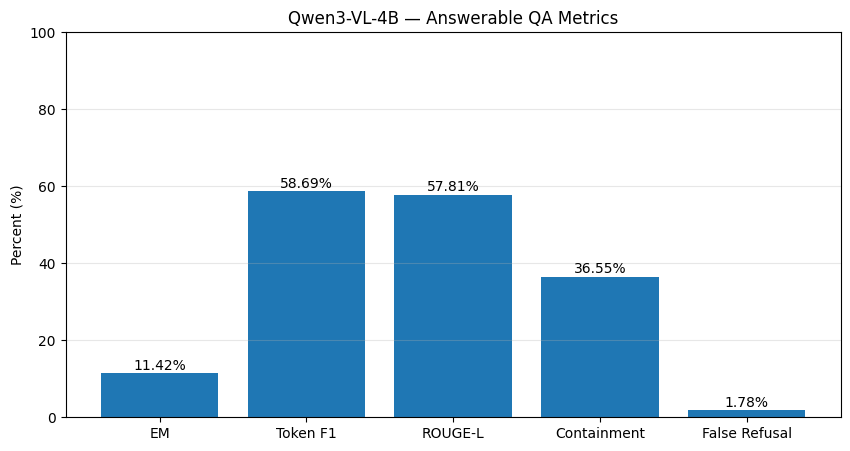

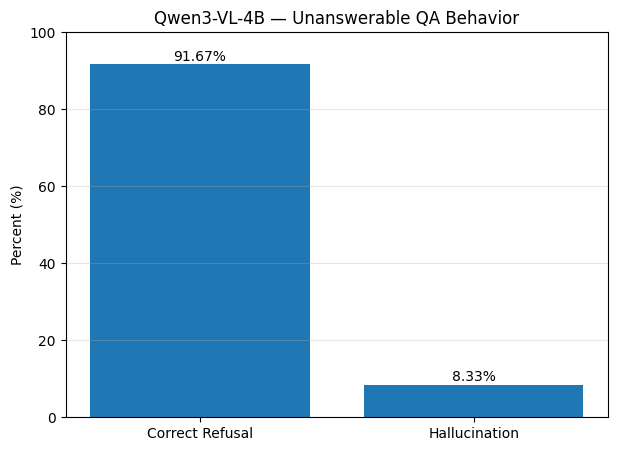

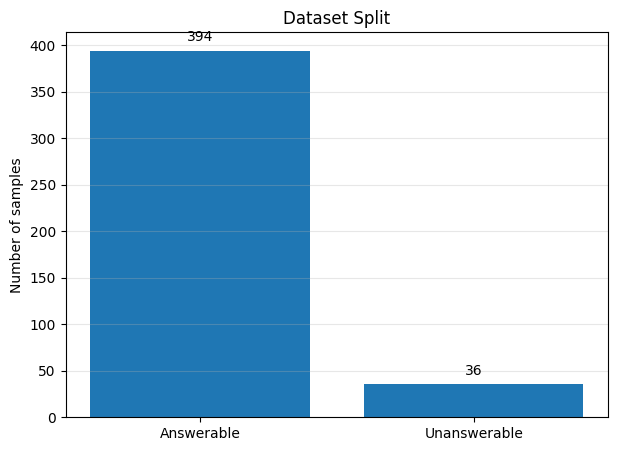

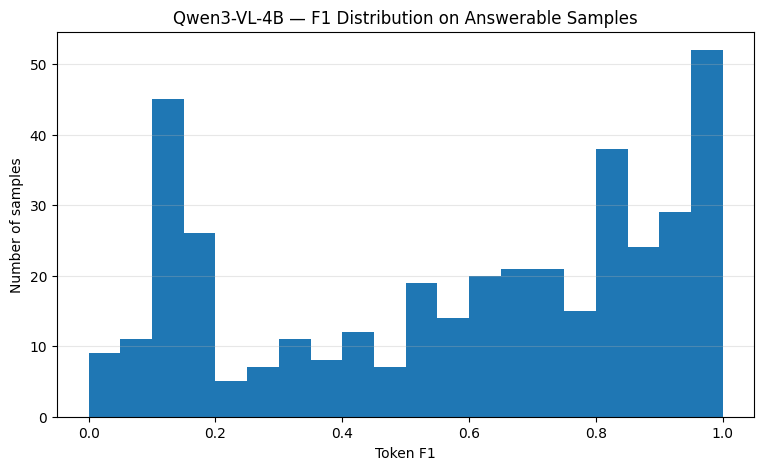


✅ Qwen fixed benchmark results saved to:
/home/drnguyenvinh/Exam-Assistant/Bench_mark/benchmark_outputs/qwen3_vl_4b_finetuned(qlora)_domain_test_20260710_152729


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 │ 💾 SAVE RESULTS + CHARTS — QWEN FIXED BENCHMARK
# ─────────────────────────────────────────────────────────────────────────────
import json
import matplotlib.pyplot as plt

results_jsonl = OUTPUT_DIR / "qwen_predictions_fixed_metrics.jsonl"
results_csv = OUTPUT_DIR / "qwen_predictions_fixed_metrics.csv"
summary_csv = OUTPUT_DIR / "qwen_summary_fixed_metrics.csv"
summary_json = OUTPUT_DIR / "qwen_summary_fixed_metrics.json"

with open(results_jsonl, "w", encoding="utf-8") as f:
    for row in rows:
        f.write(json.dumps(row, ensure_ascii=False) + "\n")

df.to_csv(results_csv, index=False, encoding="utf-8-sig")
summary_df.to_csv(summary_csv, index=False, encoding="utf-8-sig")

with open(summary_json, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("Saved fixed metrics:")
print(results_jsonl)
print(results_csv)
print(summary_csv)
print(summary_json)

# Chart 1: Answerable QA metrics
metric_names = ["EM", "Token F1", "ROUGE-L", "Containment", "False Refusal"]
metric_values = [
    summary["answerable_em"],
    summary["answerable_f1"],
    summary["answerable_rouge_l"],
    summary["answerable_containment"],
    summary["false_refusal_rate_answerable"]
]

plt.figure(figsize=(10, 5))
plt.bar(metric_names, metric_values)
plt.ylabel("Percent (%)")
plt.title("Qwen3-VL-4B — Answerable QA Metrics")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

for i, v in enumerate(metric_values):
    plt.text(i, v + 1, f"{v:.2f}%", ha="center")

chart_path = OUTPUT_DIR / "qwen_answerable_metrics.png"
plt.savefig(chart_path, dpi=200, bbox_inches="tight")
plt.show()

# Chart 2: Unanswerable behavior
metric_names = ["Correct Refusal", "Hallucination"]
metric_values = [
    summary["correct_refusal_rate_unanswerable"],
    summary["hallucination_rate_unanswerable"]
]

plt.figure(figsize=(7, 5))
plt.bar(metric_names, metric_values)
plt.ylabel("Percent (%)")
plt.title("Qwen3-VL-4B — Unanswerable QA Behavior")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

for i, v in enumerate(metric_values):
    plt.text(i, v + 1, f"{v:.2f}%", ha="center")

chart_path = OUTPUT_DIR / "qwen_unanswerable_behavior.png"
plt.savefig(chart_path, dpi=200, bbox_inches="tight")
plt.show()

# Chart 3: Dataset split
split_names = ["Answerable", "Unanswerable"]
split_values = [
    summary["answerable_samples"],
    summary["unanswerable_samples"]
]

plt.figure(figsize=(7, 5))
plt.bar(split_names, split_values)
plt.ylabel("Number of samples")
plt.title("Dataset Split")
plt.grid(axis="y", alpha=0.3)

for i, v in enumerate(split_values):
    plt.text(i, v + 10, str(v), ha="center")

chart_path = OUTPUT_DIR / "dataset_split.png"
plt.savefig(chart_path, dpi=200, bbox_inches="tight")
plt.show()

# Chart 4: F1 distribution on answerable only
plt.figure(figsize=(9, 5))
plt.hist(answerable_df["f1"], bins=20)
plt.xlabel("Token F1")
plt.ylabel("Number of samples")
plt.title("Qwen3-VL-4B — F1 Distribution on Answerable Samples")
plt.grid(axis="y", alpha=0.3)

chart_path = OUTPUT_DIR / "qwen_answerable_f1_distribution.png"
plt.savefig(chart_path, dpi=200, bbox_inches="tight")
plt.show()

print("\n✅ Qwen fixed benchmark results saved to:")
print(OUTPUT_DIR.resolve())

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 │ 📝 SAVE QWEN FIXED BENCHMARK REPORT
# ─────────────────────────────────────────────────────────────────────────────

report_path = OUTPUT_DIR / "qwen_benchmark_report_fixed_metrics.md"

report = f"""# Benchmark Report — Qwen3-VL-4B-Instruct Baseline

## Model

`{MODEL_NAME}`

## Dataset

`{DATASET_PATH}`

Number of samples: **{len(df)}**

- Answerable samples: **{summary["answerable_samples"]}**
- Unanswerable samples: **{summary["unanswerable_samples"]}**

## Main Results

### Answerable QA

| Metric | Value |
|---|---:|
| Answerable EM | {summary["answerable_em"]:.2f}% |
| Answerable Token F1 | {summary["answerable_f1"]:.2f}% |
| Answerable ROUGE-L | {summary["answerable_rouge_l"]:.2f}% |
| Containment Accuracy | {summary["answerable_containment"]:.2f}% |
| False Refusal Rate | {summary["false_refusal_rate_answerable"]:.2f}% |

### Unanswerable QA

| Metric | Value |
|---|---:|
| Correct Refusal Rate | {summary["correct_refusal_rate_unanswerable"]:.2f}% |
| Hallucination Rate on Unanswerable | {summary["hallucination_rate_unanswerable"]:.2f}% |

### Overall

| Metric | Value |
|---|---:|
| Overall EM | {summary["overall_em"]:.2f}% |
| Overall Token F1 | {summary["overall_f1"]:.2f}% |
| Overall ROUGE-L | {summary["overall_rouge_l"]:.2f}% |
| Average Latency | {summary["avg_latency_sec"]:.4f} sec/sample |
| Throughput | {summary["throughput_samples_per_sec"]:.2f} samples/sec |

## Interpretation

This benchmark follows a SQuAD2.0 / ViQuAD2.0-style evaluation because the dataset contains both answerable and unanswerable questions.

For answerable samples, EM, Token F1, ROUGE-L, and Containment Accuracy measure answer quality. Containment Accuracy is useful when the model generates a complete sentence while the gold answer is a short span.

For unanswerable samples, Correct Refusal Rate measures whether the model correctly refuses to answer when the context does not contain the answer. Hallucination Rate measures cases where the model produces an answer despite the gold label being unanswerable.

## Output Files

- `qwen_predictions_fixed_metrics.jsonl`
- `qwen_predictions_fixed_metrics.csv`
- `qwen_summary_fixed_metrics.csv`
- `qwen_summary_fixed_metrics.json`
- `qwen_answerable_metrics.png`
- `qwen_unanswerable_behavior.png`
- `dataset_split.png`
- `qwen_answerable_f1_distribution.png`
"""

with open(report_path, "w", encoding="utf-8") as f:
    f.write(report)

print("✅ Qwen fixed report saved:")
print(report_path.resolve())

✅ Qwen fixed report saved:
/home/drnguyenvinh/Exam-Assistant/Bench_mark/benchmark_outputs/qwen3_vl_4b_finetuned(qlora)_domain_test_20260710_152729/qwen_benchmark_report_fixed_metrics.md


In [7]:
print(prompts[0])
print(predictions[0])

<|im_start|>system
Bạn là trợ lý AI hỗ trợ giám thị coi thi. Chỉ trả lời dựa trên ngữ cảnh được cung cấp. Trả lời ngắn gọn, chính xác và không suy diễn ngoài dữ liệu.<|im_end|>
<|im_start|>user
Context:
Sự cố 01. Tài khoản đăng nhập EOS và quản lý mật khẩu. Trong kỳ thi EOS, mạng Wi-Fi sử dụng để làm bài là FU-Exam với mật khẩu FU-Exam@. Tài khoản đăng nhập hệ thống thi EOS/PEA chính là tài khoản Wi-Fi FU-Student của sinh viên. Do đó, nếu sinh viên quên mật khẩu đăng nhập EOS thì cần kiểm tra hoặc đặt lại mật khẩu tài khoản Wi-Fi FU-Student. Nếu sinh viên không nhớ mật khẩu Wi-Fi FU-Student, trước tiên cần kiểm tra hộp thư email bằng cách tìm kiếm các từ khóa như Wifi, EOS, IT, Account hoặc Pass để tìm email chứa thông tin tài khoản do nhà trường gửi. Nếu cần đổi mật khẩu, sinh viên truy cập http://reset.fun.cantho/, nhập tài khoản đăng nhập và địa chỉ email để nhận mật khẩu tạm thời. Sau khi nhận email, sinh viên quay lại trang reset, nhập Username, Old Password (mật khẩu tạm thời), s

In [8]:
df["gold_len_words"].describe()
df["pred_len_words"].describe()
low_f1 = df.sort_values("f1").head(20)

for _, row in low_f1.iterrows():
    print("="*20)
    print("QUESTION:", row["question"])
    print("GOLD    :", row["gold_answer"])
    print("PRED    :", row["prediction"])
    print("F1      :", row["f1"])

QUESTION: Làm thế nào để sửa lỗi Outlook không gửi được mail?
GOLD    : Không có thông tin trong ngữ cảnh được cung cấp.
PRED    : Khởi động lại máy tính, kết nối lại Wi-Fi, khởi động lại card mạng rồi thử gửi email.
F1      : 0.0
QUESTION: Ai thực hiện ReAssign khi sinh viên đã đăng nhập trước đó?
GOLD    : Bộ phận Khảo thí thực hiện ReAssign.
PRED    : Giám thị.
F1      : 0.0
QUESTION: Nếu đã có mạng nhưng email không gửi được thì có cần kiểm tra Wi-Fi không?
GOLD    : Có. Khởi động lại máy, kết nối lại Wi-Fi rồi thử gửi email lại.
PRED    : Không.
F1      : 0.0
QUESTION: Lỗi 'Sorry, unable to verify your information' nghĩa là gì?
GOLD    : Cần kiểm tra lại User Name và Password.
PRED    : Thông tin tài khoản hoặc mật khẩu đăng nhập không chính xác.
F1      : 0.0
QUESTION: Nếu sinh viên đã được IT hỗ trợ nhưng vẫn không kết nối được Wi-Fi khi dùng USB thì làm gì?
GOLD    : Giám thị báo lên nhóm hỗ trợ chung kèm MSSV để bộ phận Khảo thí xác nhận và quyết định hướng xử lý.
PRED    : Kh

In [9]:
refusal_gold = 0

for s in samples:
    gold = s["gold_answer"].lower()

    if "tôi không tìm thấy thông tin" in gold:
        refusal_gold += 1

print("Unanswerable samples:", refusal_gold)
print("Answerable samples:", len(samples)-refusal_gold)
print("Refusal ratio:", refusal_gold/len(samples)*100)

Unanswerable samples: 0
Answerable samples: 430
Refusal ratio: 0.0
